# EDA draft — 5 biểu đồ cơ bản

Bản nháp theo DoD Người 5: phân phối lương, top kỹ năng, top địa điểm, top cấp bậc, timeline. Chạy trên dữ liệu thật đã freeze (Mốc 2) thay vì dữ liệu mẫu. Bản đầy đủ: `eda_full.ipynb`.

**Dữ liệu cần có:** `data/processed/jobs_clean.parquet` và `data/processed/skill_matrix.parquet` (tải từ Drive, hoặc chạy `python scripts/run_pipeline.py skills`). Hash phải khớp `docs/MANIFEST.json`.

Notebook chỉ hiển thị số liệu tổng hợp, **không** in nguyên văn JD (cam kết ToS, `docs/DECISIONS.md` 29/09).

In [1]:
import sys
from pathlib import Path

# Chạy được dù mở notebook từ thư mục gốc repo hay từ notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.viz.eda import FIGURES, load_data, save_figure, salary_tertiles, skill_share

# load_data() kiểm SHA-256 của jobs_clean + skill_matrix với docs/MANIFEST.json, lệch thì dừng
jobs, skills = load_data()
print(f"{len(jobs)} tin, {skills.shape[1]} kỹ năng — hash khớp docs/MANIFEST.json")

688 tin, 100 kỹ năng — hash khớp docs/MANIFEST.json


## 1. Phân phối lương (tin có công bố lương)

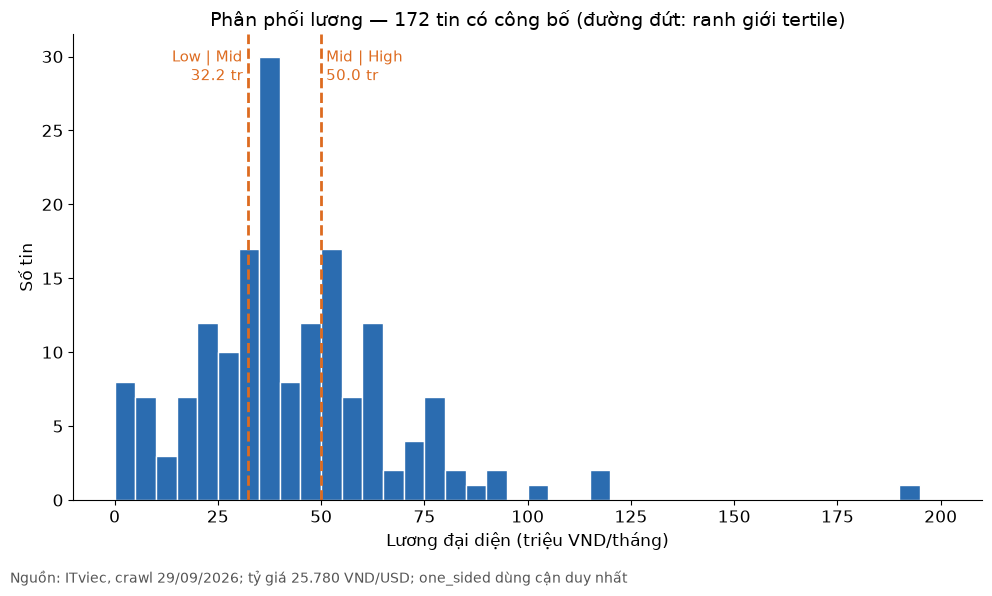

In [2]:
fig = FIGURES["salary_distribution"](jobs, skills)

## 2. Top kỹ năng

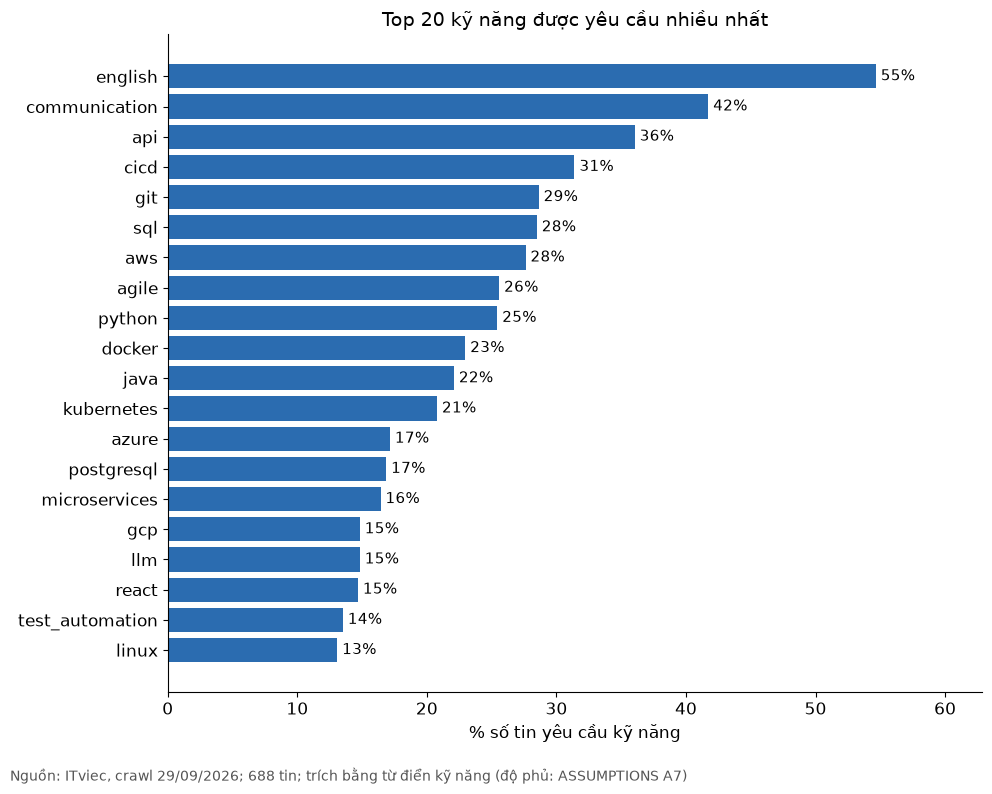

In [3]:
fig = FIGURES["top_skills"](jobs, skills)

## 3. Địa điểm

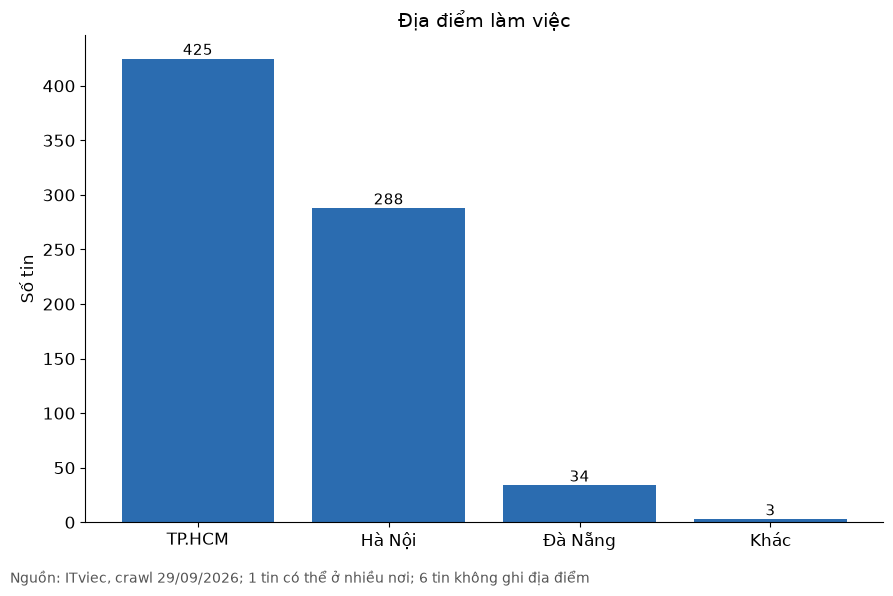

In [4]:
fig = FIGURES["locations"](jobs, skills)

## 4. Cấp bậc

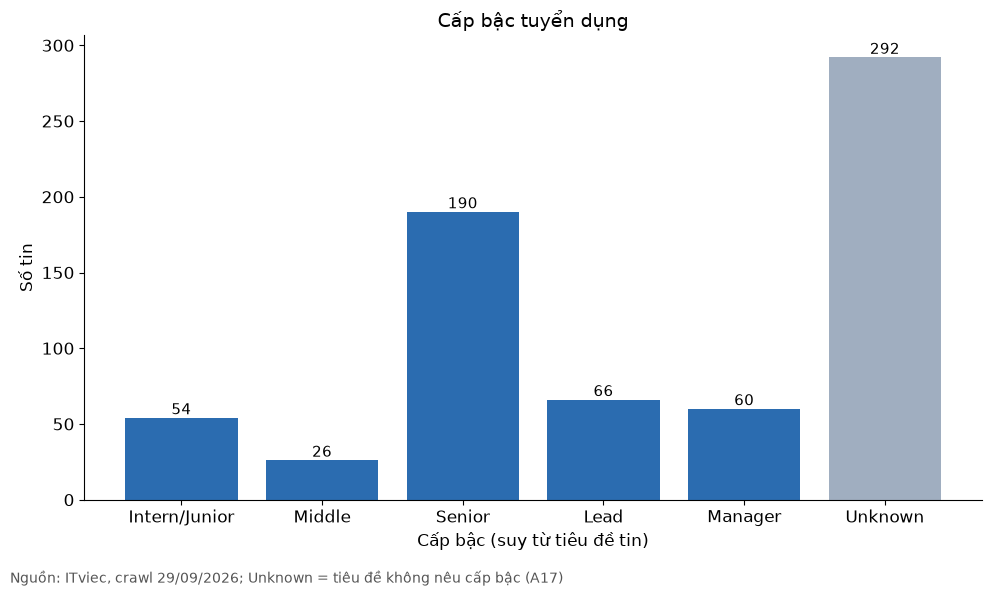

In [5]:
fig = FIGURES["levels"](jobs, skills)

## 5. Timeline đăng tin

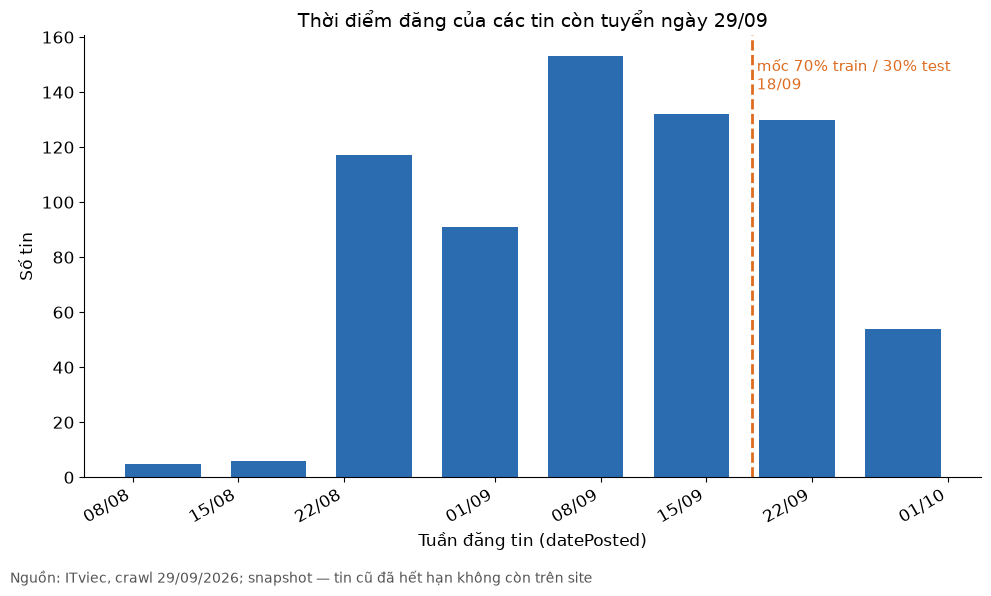

In [6]:
fig = FIGURES["timeline"](jobs, skills)